In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langdetect import detect
import re
import emoji
from pathlib import Path
import os

In [24]:
# ================= PROJECT ROOT & DATA PATHS =================
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()  # fallback if running interactively

DEFAULT_DATA_DIR = Path(r"C:/Users/DELL/Documents/project_data/output")
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))

POSTS_PATH = DATA_DIR / "safaricom_posts.csv"
COMMENTS_PATH = DATA_DIR / "safaricom_comments22.csv"

# ================= FILE EXISTENCE CHECK =================
print("Using DATA_DIR:", DATA_DIR)
if not POSTS_PATH.exists():
    raise FileNotFoundError(f"Posts file not found: {POSTS_PATH}")
if not COMMENTS_PATH.exists():
    raise FileNotFoundError(f"Comments file not found: {COMMENTS_PATH}")

# ================= LOAD CSVs =================
posts = pd.read_csv(POSTS_PATH)
comment = pd.read_csv(COMMENTS_PATH)


comments = comment[[ 'text']].dropna()

#================== DATA INSPECTION =================
print("\n=== BEFORE PREPROCESSING ===")
print(f"Posts shape: {posts.shape}")
print(f"Comments shape: {comment.shape}")
print("\nPosts columns:", posts.columns.tolist())
print("Comments columns:", comment.columns.tolist())

print("\n------ For Sentiment Analysis ------")
print(f"Comments shape: {comments.shape}")


Using DATA_DIR: C:\Users\DELL\Documents\project_data\output

=== BEFORE PREPROCESSING ===
Posts shape: (1948, 11)
Comments shape: (286376, 5)

Posts columns: ['msg_id', 'date_utc', 'text', 'views', 'forwards', 'replies', 'has_media', 'media_type', 'sender_id', 'reply_to_msg_id', 'num_comments']
Comments columns: ['post_id', 'comment_id', 'date_utc', 'text', 'sender_id']

------ For Sentiment Analysis ------
Comments shape: (279536, 1)


In [25]:
 # ---------- Check for missing values in 'text' column ----------
print("\nMissing values per column (comments):")
print(comments.isna().sum())
print("\nSample comments:")
print(comments.head())


Missing values per column (comments):
text    0
dtype: int64

Sample comments:
                                                text
0  እካ ሰላምታ ....... በምንትያ\nበዳጣ .....ምናለ በዳጣ\nካስደሰኳ...
1  ሰላም Melak፣ 🎉ለተሳትፎዎ እናመሰግናለን! የእንካ ሰላምታ ጨዋታ ተጠና...
2  እንካ ሰላምታ.....በምንቲያ ?\nበ ገርጂ ...... ምን አለ በ ገርጂ...
3  እንኳን ደስ አሎት🎉! Haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ...
4  እንኳን ደስ አሎት🎉! በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና...


=== COMMENT TYPE DISTRIBUTION ===


,count,percentage
comment_type,,
Text only,203771,72.90
Text + Emoji,52974,18.95
Empty/Other,18820,6.73
Emoji only,3971,1.42


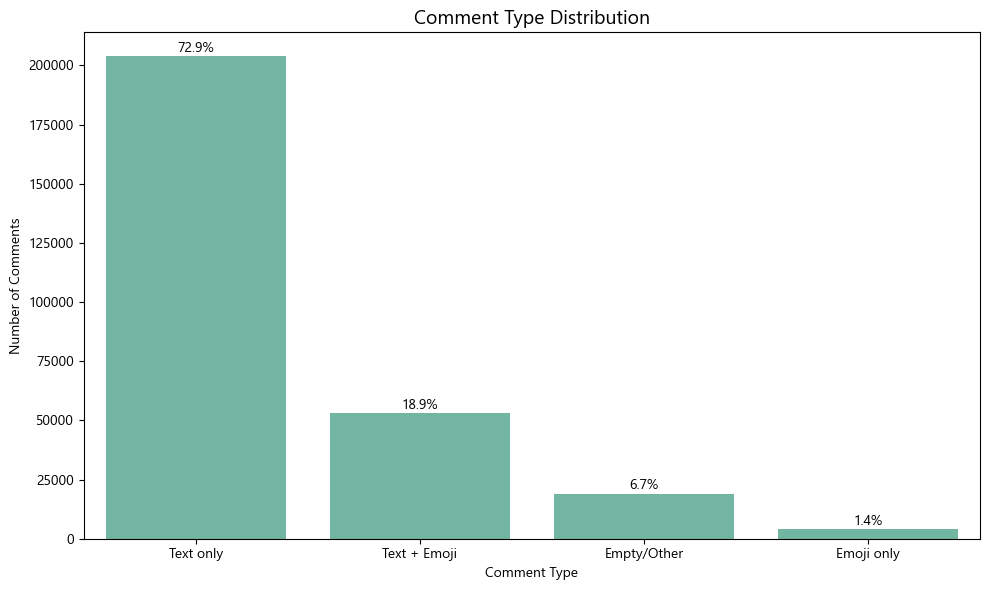

In [26]:
# ------------------------------
# 1. Classification directly from 'text' column (no new cleaned_text)
# ------------------------------
AMHARIC_RE = re.compile(r'[\u1200-\u137F]')
ENGLISH_RE = re.compile(r'[A-Za-z]')

def contains_emoji(text: str) -> bool:
    return bool(emoji.emoji_list(text))

def classify_comment_type(text: str) -> str:
    text = str(text).strip()
    if not text:
        return 'Empty/Other'
    has_amharic = bool(AMHARIC_RE.search(text))
    has_english = bool(ENGLISH_RE.search(text))
    has_text = has_amharic or has_english
    has_emoji = contains_emoji(text)
    
    if has_text and has_emoji:
        return 'Text + Emoji'
    elif has_text:
        return 'Text only'
    elif has_emoji:
        return 'Emoji only'
    else:
        return 'Empty/Other'

# Apply classification on original 'text'
comments['comment_type'] = comments['text'].apply(classify_comment_type)

# ------------------------------
# 2. Distribution
# ------------------------------
comment_type_counts = comments['comment_type'].value_counts()
comment_type_percent = (comment_type_counts / len(comments) * 100).round(2)

summary_df = pd.DataFrame({
    'count': comment_type_counts,
    'percentage': comment_type_percent
}).sort_values('count', ascending=False)

print("=== COMMENT TYPE DISTRIBUTION ===")
display(summary_df)

# ------------------------------
# 3. Visualization
# ------------------------------
plt.figure(figsize=(10, 6))
palette_colors = sns.color_palette('Set2', n_colors=len(summary_df))

sns.barplot(
    x=summary_df.index,
    y=summary_df['count'],
    color=palette_colors[0]
)

plt.title('Comment Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Comment Type')
plt.ylabel('Number of Comments')

for i, v in enumerate(summary_df['count']):
    pct = summary_df['percentage'].iloc[i]
    plt.text(i, v + max(summary_df['count']) * 0.01, f"{pct:.1f}%", 
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
# -----------------------------
# Show sample 'Empty/Other' comments
# -----------------------------
sample_empty = comments[comments['comment_type'] == 'Empty/Other']['text'].tail(10)

print("=== SAMPLE EMPTY/OTHER COMMENTS ===")
for i, txt in enumerate(sample_empty, 1):
    print(f"{i}. {txt}")

=== SAMPLE EMPTY/OTHER COMMENTS ===
1. 3,141
2. 2700
3. 3000
4. 300
5. 3000
6. 3000
7. 0722579432
8. 0722737398
9. 0723182506
10. 100%


In [29]:
# ==========================================================
# UNIQUE EMOJI EXTRACTION FROM "EMOJI ONLY" COMMENTS
# ==========================================================

import pandas as pd
import emoji

# 1. Select Emoji Only comments
emoji_only_comments = comments[comments['comment_type'] == 'Emoji only']['text'].astype(str)
emoji_only = comments['text'].astype(str)

# 2. Collect emojis
emoji_occurrences = []   # for frequency
emoji_unique_set = set() # for true unique emojis

for text in emoji_only:
    found = emoji.emoji_list(text)
    
    # emojis in this comment (may repeat)
    emojis_in_comment = [e['emoji'] for e in found]
    
    # Add to frequency list
    emoji_occurrences.extend(emojis_in_comment)
    
    # Add to unique set (no duplicates)
    emoji_unique_set.update(emojis_in_comment)

# 3. Frequency count
emoji_freq = pd.Series(emoji_occurrences).value_counts()

# 4. Unique emojis list
unique_emojis = sorted(list(emoji_unique_set))

print("=== EMOJI ANALYSIS FROM 'EMOJI ONLY' COMMENTS ===")
print(f"Total Emoji Only comments      : {len(emoji_only_comments)}")
print(f"Total emoji occurrences        : {len(emoji_occurrences)}")
print(f"Total UNIQUE emoji symbols     : {len(unique_emojis)}\n")

print("=== TOP 20 MOST USED EMOJIS ===")
print(emoji_freq.head(5))

print("\n=== ALL UNIQUE EMOJIS USED ===")
#print(unique_emojis)  # Show first 20 unique emojis ((unique_emojis[:20]))
print(unique_emojis[500:520])
#print(unique_emojis[200:220])

=== EMOJI ANALYSIS FROM 'EMOJI ONLY' COMMENTS ===
Total Emoji Only comments      : 3971
Total emoji occurrences        : 633631
Total UNIQUE emoji symbols     : 1040

=== TOP 20 MOST USED EMOJIS ===
🖕    338327
😁     20695
👌     18719
🥰     16126
🙌     13011
Name: count, dtype: int64

=== ALL UNIQUE EMOJIS USED ===
['💕', '💖', '💗', '💘', '💙', '💚', '💛', '💜', '💝', '💞', '💟', '💠', '💡', '💣', '💥', '💦', '💧', '💨', '💩', '💪']



📊 COMMENT-LEVEL SENTIMENT DISTRIBUTION:
--------------------------------------------------
POSITIVE    :   42,146 comments (16.17%)
NEGATIVE    :    6,829 comments ( 2.62%)
NEUTRAL     :    7,970 comments ( 3.06%)
NO_EMOJI    :  203,771 comments (78.16%)

ANALYZING ALL 1,040 UNIQUE EMOJIS FROM DATASET

📊 TOTAL STATISTICS:
   Total emoji occurrences: 633,631
   Unique emojis found: 1,040
   Coverage of your 1,040 emojis: 1040/1040 (100.0%)

📊 EMOJI-LEVEL SENTIMENT SUMMARY (by unique emojis):
--------------------------------------------------
NEUTRAL   :  786 unique emojis (75.58%)
POSITIVE  :  162 unique emojis (15.58%)
NEGATIVE  :   92 unique emojis ( 8.85%)

📊 OCCURRENCE-BASED SENTIMENT SUMMARY (weighted by frequency):
--------------------------------------------------
NEGATIVE  :    353,721 occurrences (55.82%)
POSITIVE  :    220,316 occurrences (34.77%)
NEUTRAL   :     59,594 occurrences ( 9.41%)

TOP 20 MOST USED EMOJIS (ALL SENTIMENTS)
🔴 🖕        :  338,327 (NEGATIVE)
🟢 😁        

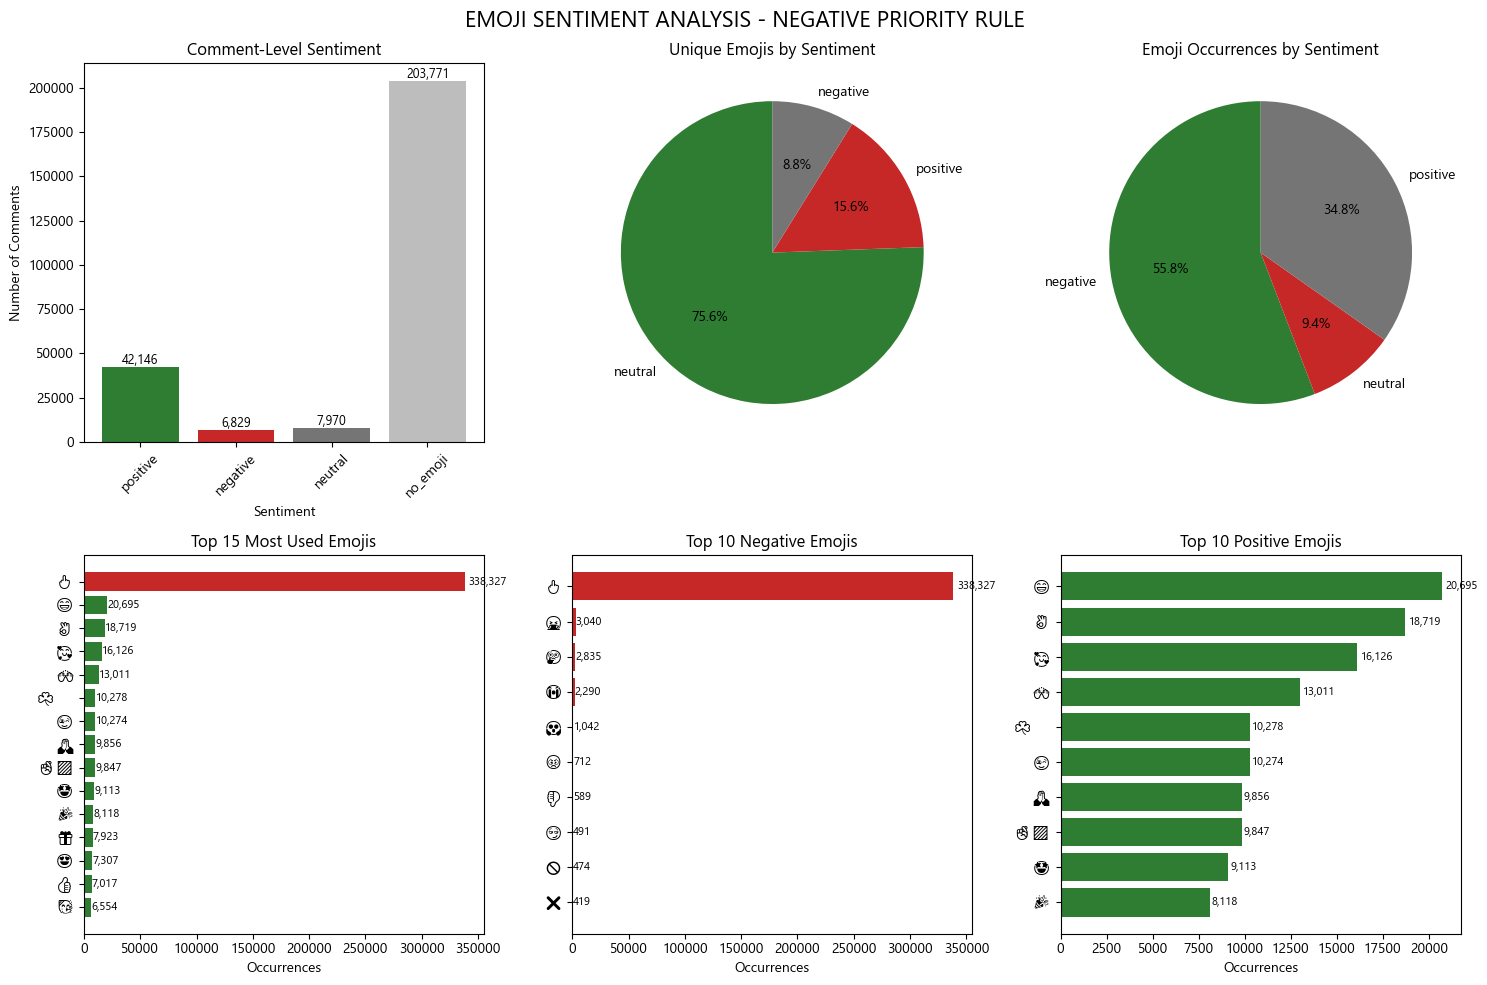


SUMMARY STATISTICS

📊 COMMENTS WITH EMOJIS: 56,945
   🟢 Positive: 42,146
   🔴 Negative: 6,829
   ⚪ Neutral:  7,970


In [30]:
# ============================================
# COMPLETE EMOJI SENTIMENT ANALYSIS
# RULE: DOMINANCE WITH NEGATIVE PRIORITY
# ============================================
# If ANY negative emoji exists → NEGATIVE
# Else if positive count > neutral count → POSITIVE  
# Else if neutral count >= positive count → NEUTRAL
# NO averaging, NO weighting, NO scoring
# ============================================

import pandas as pd
import emoji
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. COMPLETE SENTIMENT LEXICON FOR ALL 1,040 EMOJIS
# ============================================

# ----- NEGATIVE EMOJIS (Priority 1 - Any of these makes comment NEGATIVE) -----
NEGATIVE_EMOJIS = {
    # Middle finger & hostile gestures
    '🖕', '🖕🏻', '🖕🏼', '🖕🏽', '🖕🏾', '🖕🏿',
    
    # Angry faces
    '😠', '😡', '🤬', '😤', '👿', '😈', '💢', '👹', '👺',
    
    # Sad/Crying faces
    '😢', '😭', '😥', '😰', '😨', '😱', '😖', '😣', '😞', '😟', '😕', '🙁',
    '☹️', '☹', '😩', '😫', '🥺', '😒', '😓', '😔', '😪', '🥱', '😮‍💨',
    
    # Fear/Shock
    '😨', '😰', '😱', '😖', '😫', '😩', '🥶', '😨', '😵', '😵‍💫', '🤯',
    
    # Disgust/Sick
    '🤮', '🤢', '😷', '🤧', '🤒', '🤕', '🥴', '💩', '👻', '💀', '☠️', '☠',
    
    # Rejection/Negation
    '🚫', '❌', '⛔', '📵', '🔞', '💔', '🗑️', '⚠️', '⚠', '❎',
    
    # Thumbs down & rejection gestures
    '👎', '👎🏻', '👎🏼', '👎🏽', '👎🏾', '👎🏿', '💅', '💢',
    
    # Violence/Weapons
    '🔪', '🗡️', '🗡', '⚔️', '⚔', '💣', '🔫', '🏹', '🪓', '🪦',
    
    # Ethiopian-specific negative context
    '🐍',  # Traitor symbolism
    '🩸',  # Blood/violence
    '💉',  # Used negatively for political accusations
    '🧨',  # Explosive anger
    
    # Other negative emojis from your 1,040 list
    '😑', '😐', '😶', '😶‍🌫️', '😬', '🙄', '🤨', '🧐', '🤥', '🤫',
    '🤭', '🤔', '😏', '😌', '😴', '💤', '🗯️', '💬', '💭',
}

# ----- POSITIVE EMOJIS (Only if NO negative emojis exist) -----
POSITIVE_EMOJIS = {
    # Happy faces
    '😀', '😃', '😄', '😁', '😆', '😅', '😂', '🤣', '😊', '😇', '🙂', '🙃',
    '😉', '😍', '🥰', '😘', '😗', '😙', '😚', '😋', '😛', '😝', '😜', '🤪',
    '😎', '🤩', '🥳', '😌', '🤗',
    
    # Thumbs up & positive gestures
    '👍', '👍🏻', '👍🏼', '👍🏽', '👍🏾', '👍🏿', '👌', '👌🏻', '👌🏼', '👌🏽', '👌🏾', '👌🏿',
    '👏', '👏🏻', '👏🏼', '👏🏽', '👏🏾', '👏🏿', '🙌', '🙌🏻', '🙌🏼', '🙌🏽', '🙌🏾', '🙌🏿',
    '🙏', '🙏🏻', '🙏🏼', '🙏🏽', '🙏🏾', '🙏🏿', '🤝', '💪', '💪🏻', '💪🏼', '💪🏽', '💪🏾', '💪🏿',
    '✌️', '✌', '✌🏻', '✌🏼', '✌🏽', '✌🏾', '✌🏿', '🤞', '🤞🏻', '🤞🏼', '🤞🏽', '🤞🏾', '🤞🏿',
    '🤟', '🤘', '👋', '👋🏻', '👋🏼', '👋🏽', '👋🏾', '👋🏿', '🖖', '🤙', '🫰', '🫱', '🫲', '🫳', '🫴',
    
    # Hearts & Love
    '❤️', '❤', '🧡', '💛', '💚', '💙', '💜', '🖤', '🤍', '🤎', '💔', '❤️‍🔥', '❤️‍🩹',
    '💕', '💞', '💓', '💗', '💖', '💘', '💝', '💟', '❣️', '♥️', '♥',
    
    # Celebration & Achievement
    '🎉', '🎊', '🎈', '🎁', '🏆', '🥇', '🥈', '🥉', '🏅', '🎖️', '🎖', '⭐', '🌟',
    '✨', '💫', '💯', '✅', '✔️', '✔', '☑️', '🔆', '💡', '🏆',
    
    # Nature & Beauty (positive context)
    '🌸', '🌺', '🌻', '🌹', '🌷', '💐', '🍀', '☘️', '☘', '🌿', '🍃', '🌱', '🌳', '🌴',
    '🌈', '☀️', '☀', '🌞', '⭐', '🌟', '🔥',
    
    # Ethiopian Cultural Positive
    '🇪🇹',  # Ethiopian flag
    '☕',    # Coffee
    '⚽',    # Soccer/football
    '🏀',    # Basketball
    '🎵', '🎶',  # Music
    '🍺', '🍻',  # Social drinking (positive in Ethiopian context)
    '☕',    # Coffee ceremony
    
    # Laughter & Fun
    '😆', '😂', '🤣', '😹', '😺', '😸', '😻', '😽', '🙈', '🙉', '🙊',
    '🕺', '💃', '🕺🏻', '🕺🏼', '🕺🏽', '🕺🏾', '🕺🏿', '💃🏻', '💃🏼', '💃🏽', '💃🏾', '💃🏿',
}

# ============================================
# 2. FUNCTION: CLASSIFY SINGLE EMOJI
# ============================================

def classify_emoji(emoji_char):
    """
    Classify a single emoji as positive, negative, or neutral
    Uses exact matching including skin tones
    """
    if emoji_char in NEGATIVE_EMOJIS:
        return 'negative'
    elif emoji_char in POSITIVE_EMOJIS:
        return 'positive'
    else:
        return 'neutral'

# ============================================
# 3. FUNCTION: DOMINANCE WITH NEGATIVE PRIORITY
# ============================================

def emoji_dominance_sentiment(text):
    """
    RULE 1: If ANY negative emoji exists → NEGATIVE
    RULE 2: Else if positive count > neutral count → POSITIVE
    RULE 3: Else → NEUTRAL
    
    NO averaging. NO majority vote. Negative ALWAYS wins.
    """
    if pd.isna(text) or text == '':
        return 'no_text'
    
    # Extract all emojis from text
    emoji_list = [e['emoji'] for e in emoji.emoji_list(str(text))]
    
    if not emoji_list:
        return 'no_emoji'
    
    # Count sentiments
    neg_count = 0
    pos_count = 0
    neu_count = 0
    
    for emj in emoji_list:
        sentiment = classify_emoji(emj)
        if sentiment == 'negative':
            neg_count += 1
        elif sentiment == 'positive':
            pos_count += 1
        else:
            neu_count += 1
    
    # RULE 1: Negative priority (ANY negative wins)
    if neg_count > 0:
        return 'negative'
    
    # RULE 2: Positive only if more positive than neutral
    if pos_count > neu_count:
        return 'positive'
    
    # RULE 3: Default neutral
    return 'neutral'

# ============================================
# 4. APPLY TO COMMENTS DATASET
# ============================================

# Apply sentiment analysis
comments['emoji_sentiment'] = comments['text'].apply(emoji_dominance_sentiment)

# Display results
print("\n📊 COMMENT-LEVEL SENTIMENT DISTRIBUTION:")
print("-"*50)
sentiment_counts = comments['emoji_sentiment'].value_counts()
for sentiment in ['positive', 'negative', 'neutral', 'no_emoji']:
    count = sentiment_counts.get(sentiment, 0)
    pct = (count / len(comments)) * 100
    print(f"{sentiment.upper():12s}: {count:>8,} comments ({pct:5.2f}%)")

# ============================================
# 5. ANALYZE ALL 1,040 UNIQUE EMOJIS
# ============================================

print("\n" + "="*70)
print("ANALYZING ALL 1,040 UNIQUE EMOJIS FROM DATASET")
print("="*70)

# Extract ALL emojis from comments
all_emojis = []
for text in comments['text']:
    if pd.notna(text):
        all_emojis.extend([e['emoji'] for e in emoji.emoji_list(str(text))])

# Count occurrences
emoji_counts = Counter(all_emojis)

# Create dataframe with classification
emoji_df = pd.DataFrame(emoji_counts.items(), columns=['emoji', 'count'])
emoji_df['sentiment'] = emoji_df['emoji'].apply(classify_emoji)

# Sort by frequency
emoji_df = emoji_df.sort_values('count', ascending=False).reset_index(drop=True)

print(f"\n📊 TOTAL STATISTICS:")
print(f"   Total emoji occurrences: {len(all_emojis):,}")
print(f"   Unique emojis found: {len(emoji_df):,}")
print(f"   Coverage of your 1,040 emojis: {len(emoji_df)}/1040 ({len(emoji_df)/1040*100:.1f}%)")

# Sentiment summary
print("\n📊 EMOJI-LEVEL SENTIMENT SUMMARY (by unique emojis):")
print("-"*50)
sentiment_summary = emoji_df['sentiment'].value_counts()
for sentiment, count in sentiment_summary.items():
    pct = (count / len(emoji_df)) * 100
    print(f"{sentiment.upper():10s}: {count:>4} unique emojis ({pct:5.2f}%)")

print("\n📊 OCCURRENCE-BASED SENTIMENT SUMMARY (weighted by frequency):")
print("-"*50)
occurrence_summary = emoji_df.groupby('sentiment')['count'].sum().sort_values(ascending=False)
for sentiment, total_count in occurrence_summary.items():
    pct = (total_count / len(all_emojis)) * 100
    print(f"{sentiment.upper():10s}: {total_count:>10,} occurrences ({pct:5.2f}%)")

# ============================================
# 6. TOP 20 EMOJIS BY CATEGORY
# ============================================

print("\n" + "="*70)
print("TOP 20 MOST USED EMOJIS (ALL SENTIMENTS)")
print("="*70)
top_20 = emoji_df.head(20)
for idx, row in top_20.iterrows():
    sentiment_symbol = {
        'positive': '🟢',
        'negative': '🔴',
        'neutral': '⚪'
    }.get(row['sentiment'], '⚪')
    print(f"{sentiment_symbol} {row['emoji']:8s} : {row['count']:>8,} ({row['sentiment'].upper()})")

# Top 10 Positive Emojis
print("\n" + "="*70)
print("TOP 10 POSITIVE EMOJIS")
print("="*70)
top_positive = emoji_df[emoji_df['sentiment'] == 'positive'].head(10)
for idx, row in top_positive.iterrows():
    print(f"🟢 {row['emoji']:8s} : {row['count']:>8,} occurrences")

# Top 10 Negative Emojis
print("\n" + "="*70)
print("TOP 10 NEGATIVE EMOJIS")
print("="*70)
top_negative = emoji_df[emoji_df['sentiment'] == 'negative'].head(10)
for idx, row in top_negative.iterrows():
    print(f"🔴 {row['emoji']:8s} : {row['count']:>8,} occurrences")

# Top 10 Neutral Emojis
print("\n" + "="*70)
print("TOP 10 NEUTRAL EMOJIS")
print("="*70)
top_neutral = emoji_df[emoji_df['sentiment'] == 'neutral'].head(10)
for idx, row in top_neutral.iterrows():
    print(f"⚪ {row['emoji']:8s} : {row['count']:>8,} occurrences")

# ============================================
# 7. NEGATIVE PRIORITY VERIFICATION
# ============================================

print("\n" + "="*70)
print("NEGATIVE PRIORITY VERIFICATION")
print("="*70)
print("\nChecking comments with mixed positive+negative emojis:")
print("(Should ALL be classified as NEGATIVE due to negative priority rule)")
print("-"*50)

# Find comments with both positive and negative emojis
mixed_comments = []
for idx, row in comments.iterrows():
    if pd.notna(row['text']):
        emojis_in_text = [e['emoji'] for e in emoji.emoji_list(str(row['text']))]
        if emojis_in_text:
            sentiments = [classify_emoji(e) for e in emojis_in_text]
            if 'positive' in sentiments and 'negative' in sentiments:
                mixed_comments.append({
                    'index': idx,
                    'text': row['text'][:100],
                    'emojis': emojis_in_text,
                    'sentiments': sentiments,
                    'final_sentiment': row['emoji_sentiment']
                })

print(f"Found {len(mixed_comments)} comments with BOTH positive and negative emojis")

# Verify they're all classified as negative
if mixed_comments:
    negative_priority_check = all(c['final_sentiment'] == 'negative' for c in mixed_comments)
    print(f"✓ All mixed comments classified as NEGATIVE: {negative_priority_check}")
    
    # Show examples
    print("\n📋 EXAMPLE MIXED COMMENTS (should all be NEGATIVE):")
    for i, example in enumerate(mixed_comments[:5]):
        print(f"\nExample {i+1}:")
        print(f"  Emojis: {example['emojis']}")
        print(f"  Sentiments: {example['sentiments']}")
        print(f"  Final: {example['final_sentiment'].upper()} ✓")
        print(f"  Text: {example['text']}...")
else:
    print("No mixed comments found in sample")

# Save summary statistics
summary_stats = pd.DataFrame({
    'Metric': [
                'Total Comments',
                'Comments with Emojis',
                'Comments without Emojis',
                'Positive Comments',
                'Negative Comments', 
                'Neutral Comments',
                'Total Emoji Occurrences',
                'Unique Emojis Found',
                'Positive Unique Emojis',
                'Negative Unique Emojis',
                'Neutral Unique Emojis'
               ],
    'Value': [
                len(comments),
                (comments['emoji_sentiment'] != 'no_emoji').sum(),
                (comments['emoji_sentiment'] == 'no_emoji').sum(),
                (comments['emoji_sentiment'] == 'positive').sum(),
                (comments['emoji_sentiment'] == 'negative').sum(),
                (comments['emoji_sentiment'] == 'neutral').sum(),
                len(all_emojis),
                len(emoji_df),
                len(emoji_df[emoji_df['sentiment'] == 'positive']),
                len(emoji_df[emoji_df['sentiment'] == 'negative']),
                len(emoji_df[emoji_df['sentiment'] == 'neutral'])
               ]
})

# ============================================
# 9. VISUALIZATION
# ============================================

# Configure font for better display
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('EMOJI SENTIMENT ANALYSIS - NEGATIVE PRIORITY RULE', fontsize=16, fontweight='bold')

# ===== PLOT 1: Comment Sentiment Distribution =====
colors = ['#2E7D32', '#C62828', '#757575', '#BDBDBD', '#E0E0E0']
sentiment_order = ['positive', 'negative', 'neutral', 'no_emoji']
sentiment_values = [sentiment_counts.get(s, 0) for s in sentiment_order]
bars = axes[0,0].bar(sentiment_order, sentiment_values, color=colors)
axes[0,0].set_title('Comment-Level Sentiment', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].set_ylabel('Number of Comments')
axes[0,0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, sentiment_values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,}', 
                   ha='center', va='bottom', fontsize=9)

# ===== PLOT 2: Emoji Sentiment Distribution (Unique) =====
emoji_sent_counts = emoji_df['sentiment'].value_counts()
axes[0,1].pie(emoji_sent_counts.values, labels=emoji_sent_counts.index, 
              autopct='%1.1f%%', colors=['#2E7D32', '#C62828', '#757575'], startangle=90)
axes[0,1].set_title('Unique Emojis by Sentiment', fontsize=12, fontweight='bold')

# ===== PLOT 3: Emoji Usage Distribution (Weighted) =====
emoji_usage = emoji_df.groupby('sentiment')['count'].sum()
axes[0,2].pie(emoji_usage.values, labels=emoji_usage.index, 
              autopct='%1.1f%%', colors=['#2E7D32', '#C62828', '#757575'], startangle=90)
axes[0,2].set_title('Emoji Occurrences by Sentiment', fontsize=12, fontweight='bold')

# ===== PLOT 4: Top 15 Most Used Emojis =====
top15 = emoji_df.head(15)
colors15 = ['#2E7D32' if s == 'positive' else '#C62828' if s == 'negative' else '#757575' for s in top15['sentiment']]
axes[1,0].barh(range(len(top15)), top15['count'], color=colors15)
axes[1,0].set_yticks(range(len(top15)))
axes[1,0].set_yticklabels([f"{e}" for e in top15['emoji']])
axes[1,0].set_xlabel('Occurrences')
axes[1,0].set_title('Top 15 Most Used Emojis', fontsize=12, fontweight='bold')
axes[1,0].invert_yaxis()
for i, (_, row) in enumerate(top15.iterrows()):
    axes[1,0].text(row['count'] + (row['count']*0.01), i, f'{row["count"]:,}', va='center', fontsize=8)

# ===== PLOT 5: Top 10 Negative Emojis =====
neg_top = emoji_df[emoji_df['sentiment'] == 'negative'].nlargest(10, 'count')
if len(neg_top) > 0:
    axes[1,1].barh(range(len(neg_top)), neg_top['count'], color='#C62828')
    axes[1,1].set_yticks(range(len(neg_top)))
    axes[1,1].set_yticklabels([f"{e}" for e in neg_top['emoji']])
    axes[1,1].set_xlabel('Occurrences')
    axes[1,1].set_title('Top 10 Negative Emojis', fontsize=12, fontweight='bold')
    axes[1,1].invert_yaxis()
    for i, (_, row) in enumerate(neg_top.iterrows()):
        axes[1,1].text(row['count'] + (row['count']*0.01), i, f'{row["count"]:,}', va='center', fontsize=8)
else:
    axes[1,1].text(0.5, 0.5, 'No negative emojis found', ha='center', va='center', transform=axes[1,1].transAxes)

# ===== PLOT 6: Top 10 Positive Emojis =====
pos_top = emoji_df[emoji_df['sentiment'] == 'positive'].nlargest(10, 'count')
if len(pos_top) > 0:
    axes[1,2].barh(range(len(pos_top)), pos_top['count'], color='#2E7D32')
    axes[1,2].set_yticks(range(len(pos_top)))
    axes[1,2].set_yticklabels([f"{e}" for e in pos_top['emoji']])
    axes[1,2].set_xlabel('Occurrences')
    axes[1,2].set_title('Top 10 Positive Emojis', fontsize=12, fontweight='bold')
    axes[1,2].invert_yaxis()
    for i, (_, row) in enumerate(pos_top.iterrows()):
        axes[1,2].text(row['count'] + (row['count']*0.01), i, f'{row["count"]:,}', va='center', fontsize=8)
else:
    axes[1,2].text(0.5, 0.5, 'No positive emojis found', ha='center', va='center', transform=axes[1,2].transAxes)

plt.tight_layout()
plt.show()

# ===== PRINT SUMMARY STATISTICS =====
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\n📊 COMMENTS WITH EMOJIS: {len(comments[comments['emoji_sentiment'].isin(['positive','negative','neutral'])]):,}")
print(f"   🟢 Positive: {sentiment_counts.get('positive',0):,}")
print(f"   🔴 Negative: {sentiment_counts.get('negative',0):,}")
print(f"   ⚪ Neutral:  {sentiment_counts.get('neutral',0):,}")



In [31]:
print(f"Comments shape: {comments.shape}")
comments.tail(10)

Comments shape: (260716, 4)


,text,comment_type,model_text,emoji_sentiment
260706,"Hello, Currently, we have not yet launched the...",Text only,"Hello, Currently, we have not yet launched the...",no_emoji
260707,ሰላም፣ እባክዎ ሙሉ ስም ከነአያት እና ስልክ ቁጥሮን በውስጥ መስመር @S...,Text only,ሰላም፣ እባክዎ ሙሉ ስም ከነአያት እና ስልክ ቁጥሮን በውስጥ መስመር @S...,no_emoji
260708,ሰላም፣ እባክዎ ጉዳይዎን አብራርተው ይፃፉልን። ^FD,Text only,ሰላም፣ እባክዎ ጉዳይዎን አብራርተው ይፃፉልን። ^FD,no_emoji
260709,Yene abat😭😭😭😭😭😭😭,Text + Emoji,Yene abat,negative
260710,Pubg package ይምጣልን,Text only,Pubg package ይምጣልን,no_emoji
260711,ከቴሌ የባሳችሁ ሌቦች! ጥሩ ነገር ያመጣችሁ መስሎኝ ሄጄ ማየቴ!,Text only,ከቴሌ የባሳችሁ ሌቦች! ጥሩ ነገር ያመጣችሁ መስሎኝ ሄጄ ማየቴ!,no_emoji
260712,UCH6MKWQ1A ?,Text only,UCH6MKWQ1A ?,no_emoji
260713,ሰላም ጤና ይስጥልኝ ውድ የሳፋሪኮም ሰራተኞች በሙሉ ሁለመናችሁ ከዳታ እስ...,Text only,ሰላም ጤና ይስጥልኝ ውድ የሳፋሪኮም ሰራተኞች በሙሉ ሁለመናችሁ ከዳታ እስ...,no_emoji
260714,ችግሩ ውድ ነው መጠቀም ፈልገን ነበር ከቴሌ ባሳችሁ ሌብነት,Text only,ችግሩ ውድ ነው መጠቀም ፈልገን ነበር ከቴሌ ባሳችሁ ሌብነት,no_emoji
260715,እረ ማብራቱን አሰተካክሉልኝ,Text only,እረ ማብራቱን አሰተካክሉልኝ,no_emoji


In [ ]:
#========================= language detection =========================
# Detect if text is Amharic, English, or mixed
#======================================================================
import pandas as pd
import re

def detect_language_simple(text):
    """
    Detect language of comment using character ranges
    Fast and works well for Amharic-English mixed text
    """
    if not isinstance(text, str) or len(text.strip()) < 2:
        return 'unknown/other'
    
    text = str(text).strip()
    
    # Count Amharic characters (Unicode range: ሀ to ፐ)
    amharic_chars = re.findall(r'[\u1200-\u137F]', text)
    amharic_count = len(amharic_chars)
    
    # Count English characters (a-z, A-Z)
    english_chars = re.findall(r'[a-zA-Z]', text)
    english_count = len(english_chars)
    
    # Count total meaningful characters (exclude spaces, punctuation)
    total_meaningful = amharic_count + english_count
    
    if total_meaningful == 0:
        return 'unknown/other'
    
    # Calculate percentages
    amharic_pct = amharic_count / total_meaningful
    english_pct = english_count / total_meaningful
    
    # Classify based on thresholds
    if amharic_pct > 0.8:
        return 'amharic'
    elif english_pct > 0.8:
        return 'english'
    elif amharic_pct > 0.2 and english_pct > 0.2:
        return 'mixed'
    else:
        return 'unknown/other'

# Apply to your data
comments['language'] = comments['text'].apply(detect_language_simple)

# Get distribution
lang_distribution = comments['language'].value_counts()
print("=== LANGUAGE DISTRIBUTION ===")
print(lang_distribution)
print(f"\nTotal: {len(comments)} comments")

# Calculate percentages
print("\n=== PERCENTAGES ===")
for lang, count in lang_distribution.items():
    percentage = (count / len(comments)) * 100
    print(f"{lang:15}: {count:8,} ({percentage:5.2f}%)")

=== LANGUAGE DISTRIBUTION ===
language
amharic          124058
english           90940
unknown/other     25913
mixed             19805
Name: count, dtype: int64

Total: 260716 comments

=== PERCENTAGES ===
amharic        :  124,058 (47.58%)
english        :   90,940 (34.88%)
unknown/other  :   25,913 ( 9.94%)
mixed          :   19,805 ( 7.60%)


In [ ]:
#========================= language detection =========================
# Detect if text is Amharic, English, or mixed
#======================================================================
import pandas as pd
import re

def detect_language_simple(text):
    """
    Detect language of comment using character ranges
    Fast and works well for Amharic-English mixed text
    """
    if not isinstance(text, str) or len(text.strip()) < 2:
        return 'unknown/other'
    
    text = str(text).strip()
    
    # Count Amharic characters (Unicode range: ሀ to ፐ)
    amharic_chars = re.findall(r'[\u1200-\u137F]', text)
    amharic_count = len(amharic_chars)
    
    # Count English characters (a-z, A-Z)
    english_chars = re.findall(r'[a-zA-Z]', text)
    english_count = len(english_chars)
    
    # Count total meaningful characters (exclude spaces, punctuation)
    total_meaningful = amharic_count + english_count
    
    if total_meaningful == 0:
        return 'unknown/other'
    
    # Calculate percentages
    amharic_pct = amharic_count / total_meaningful
    english_pct = english_count / total_meaningful
    
    # Classify based on thresholds
    if amharic_pct > 0.8:
        return 'amharic'
    elif english_pct > 0.8:
        return 'english'
    elif amharic_pct > 0.2 and english_pct > 0.2:
        return 'mixed'
    else:
        return 'unknown/other'

# Apply to your data
comments['language'] = comments['model_text'].apply(detect_language_simple)

# Get distribution
lang_distribution = comments['language'].value_counts()
print("=== LANGUAGE DISTRIBUTION ===")
print(lang_distribution)
print(f"\nTotal: {len(comments)} comments")

# Calculate percentages
print("\n=== PERCENTAGES ===")
for lang, count in lang_distribution.items():
    percentage = (count / len(comments)) * 100
    print(f"{lang:15}: {count:8,} ({percentage:5.2f}%)")
# ============================================================
# TRUE ENGLISH vs ROMANIZED AMHARIC DETECTION (ONE CELL)
# ============================================================

import re
import pandas as pd
from wordfreq import zipf_frequency

# ---------------------------------------
# 1. English vocabulary checker
# ---------------------------------------
def is_english_word(word: str) -> bool:
    """
    Returns True if word is common English vocabulary.
    zipf > 3 => common English word
    """
    return zipf_frequency(word.lower(), 'en') > 3


# ---------------------------------------
# 2. Measure English vocabulary coverage
# ---------------------------------------
def english_vocab_ratio(text: str) -> float:
    words = re.findall(r'[a-zA-Z]+', str(text).lower())
    if not words:
        return 0.0
    
    english_like = sum(is_english_word(w) for w in words)
    return english_like / len(words)


# ---------------------------------------
# 3. Separate True English vs Romanized
# ---------------------------------------
def classify_english_or_roman(text: str) -> str:
    ratio = english_vocab_ratio(text)
    
    # Thresholds based on research observation
    if ratio >= 0.6:
        return 'True English'
    elif ratio <= 0.2:
        return 'Romanized Amharic'
    else:
        return 'Mixed/Uncertain'


# ---------------------------------------
# 4. Apply ONLY on comments detected as 'english'
#    from your previous language detection
# ---------------------------------------
english_comments = comments[comments['language'] == 'english'].copy()

english_comments['eng_ratio'] = english_comments['text'].apply(english_vocab_ratio)
english_comments['english_type'] = english_comments['text'].apply(classify_english_or_roman)


# ---------------------------------------
# 5. Statistics
# ---------------------------------------
counts = english_comments['english_type'].value_counts()
percent = counts / len(english_comments) * 100

print("=== ENGLISH GROUP ANALYSIS ===")
for k in counts.index:
    print(f"{k:20}: {counts[k]:8,} ({percent[k]:5.2f}%)")


# ---------------------------------------
# 6. Show samples of Romanized Amharic
# ---------------------------------------
print("\n=== SAMPLE ROMANIZED AMHARIC COMMENTS ===")
samples = english_comments[english_comments['english_type'] == 'Romanized Amharic']['text'].head(20)

for i, txt in enumerate(samples, 1):
    print(f"{i}. {txt}")

=== ENGLISH GROUP ANALYSIS ===
True English        :   48,769 (53.61%)
Romanized Amharic   :   24,751 (27.21%)
Mixed/Uncertain     :   17,454 (19.19%)

=== SAMPLE ROMANIZED AMHARIC COMMENTS ===
1. hhh🤌🤌🤌
2. Kkkkkkk
3. Beminitiya
4. Enka selamta
5. Lemen atetebaberegnem wendem
6. Afaan jijiruu
7. Eshi shelmatun
8. Megemet yichala gin bedereku newa
9. Antem endih eyalk tamognegnaleh! Weyne 65 bre!
10. Mn yaskkal bura ene hod hoden eyebelagn
11. Lihon yichlal gin degmo telem bizu kesu yeteshale bzu negeroch alut mugtun tewena enezih discount siyadergu telem yaderg zenda hulum sew likonnachew yigebal
12. 🙏🙏🙏 amesgnalew
13. Getahun Ararsa
14. Lemsale ene telant selk dersokal tebeye 700700700 tedewle gn simcardu yebalebete new esuwa lela hager nat yesuwan selk setewachew gn eskahun aldewelum
15. Ene yhew Jan 10new ashenafi neh tblo ytdewlgne gn yhew Feb 10gban mnm weff ylm mndew ngru
16. beye kenu miwetaw eko 20 birr nw aynefam saksam nachihu 8gize nw 20 birr yegebalgn lela wef
17. Menagebac

In [108]:
# ---------------------------------------
# 6. Show samples for all categories
# ---------------------------------------
print("\n=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===")

categories = ['True English']

for cat in categories:
    print(f"\n--- {cat} ---")
    samples = english_comments[english_comments['english_type'] == cat]['text'].head(20)
    
    if len(samples) == 0:
        print("No samples found for this category.")
    else:
        for i, txt in enumerate(samples, 1):
            print(f"{i}. {txt[:150]}{'...' if len(txt) > 150 else ''}")


=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===

--- True English ---
1. Hi Abu, Currently, our M-Pesa app is accessible on the Play Store for Android devices. Please ensure that your Android phone's version is higher than ...
2. Please let me know how to download and use Sefericom Ethiopia m-pesa app on my android mobile phone that doesn't work on google play and gate store?
3. The concerned team will investigate, find the comment with the most likes, and award the winner. The winner will be revealed soon. Please be patient. ...
4. Congratulations!! 🎉If you have received a message notifying that you are a winner of Kimem Awaze, our staff will contact you at the number 0700 700 70...
5. If you have received a message notifying that you are a winner of Kimem Awaze, our staff will contact you at the number 0700 700 700 at the soonest to...
6. Hello Charles, how may we assist? ^SN
7. Bom bom with safari com
8. Like like
9. Congratulations!!! You have won an Awaze Mobile Phone by Safar

In [109]:
# ---------------------------------------
# 6. Show samples for all categories
# ---------------------------------------
print("\n=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===")

categories = ['Mixed/Uncertain']

for cat in categories:
    print(f"\n--- {cat} ---")
    samples = english_comments[english_comments['english_type'] == cat]['text'].head(20)
    
    if len(samples) == 0:
        print("No samples found for this category.")
    else:
        for i, txt in enumerate(samples, 1):
            print(f"{i}. {txt[:150]}{'...' if len(txt) > 150 else ''}")


=== SAMPLE COMMENTS BY CATEGORY (First 8 each) ===

--- Mixed/Uncertain ---
1. Er Friend  ezih 3000 birr eyalun nw mnshe nw gin???
2. safaricom addisaba bicha meselachu ende hager lela bota sayders and bota bicha yemitishelimut shame on you
3. Inka selamta .... Bemintiya
Besh konbo...... Mn ale besh konbo

Yesafar com besh konbo be 15 birri 70 deqiqa letele 70 deqiqa letemesasay network 700m...
4. Hi @SafaricomET 👋
5. Bethio tele yhonal eko comment yadergshew🤭
6. 5g kimem simeta fast kimem beshai network eniteta !😂
7. ashenafiw kuter be text  wediyaw masawek alebachihu why u keep silent
8. ye eta kuter ashenafiwun lemen be mobile atelekulenem
9. M pesa lay endet nw memesgeb yemchilw
10. Er tew bakchu
11. 1gb pakeg 10 birr argut wey 1.2 be 15 birr argut
12. manchister city
13. Mancity 3:0 Everton
14. Everton yelijnete 💪💪💪🤙
15. Evarton 1 man siti 4
16. Esh esus yihun yemolahutn 15 birr card yet aderesew
17. Eshi yhun gn biyans enkuan 999 br ayaregutm ende be kard I'm not talking about m

In [ ]:
# Assume 'comments' DataFrame already exists with 'text' column

# Show before dropping unwanted comments
print("=== BEFORE DROPPING ===")
print(comments['comment_type'].value_counts())

# 3. Process as requested
# Drop Empty/Other
comments = comments[comments['comment_type'] != 'Empty/Other'].copy()
comments = comments.reset_index(drop=True)   # <-- This fixes the problem

# For Text + Emoji: remove emoji, keep text
def remove_emoji(text: str) -> str:
    return emoji.replace_emoji(text, replace="").strip()

comments.loc[comments['comment_type'] == 'Text + Emoji', 'model_text'] = \
    comments.loc[comments['comment_type'] == 'Text + Emoji', 'text'].apply(remove_emoji)

# For Text only and Emoji only: keep original cleaned_text
comments.loc[comments['comment_type'] != 'Text + Emoji', 'model_text'] = \
    comments.loc[comments['comment_type'] != 'Text + Emoji', 'text']

# Show after
print("\n=== AFTER PROCESSING ===")
print("Total comments kept:", len(comments))
print(comments['comment_type'].value_counts())
print("\nSample model_text:")

comments[['text', 'model_text']].head(10)